###Anomaly Detection Model

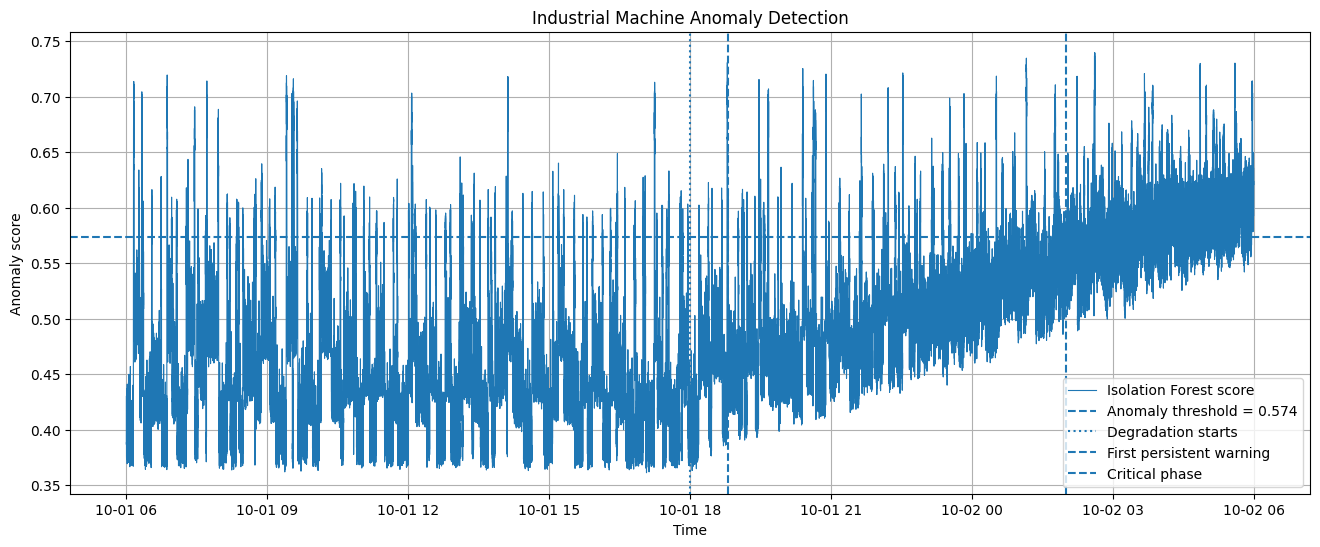

In [46]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DB_PATH = "/content/machine_telemetry_degraded.db"

with sqlite3.connect(DB_PATH) as conn:
    dataframe_machine_degraded = pd.read_sql_query(
        "SELECT * FROM machine_telemetry",
        conn,
        parse_dates=["timestamp"]
    )

dataframe_machine_degraded.head()

healthy = dataframe_machine_degraded[dataframe_machine_degraded["machine_condition"] == "HEALTHY"].copy()

print(f"Healthy observations: {len(healthy):,}")
print(f"Total observations:   {len(dataframe_machine_degraded):,}")

features = [
    "hydraulic_pressure",
    "hydraulic_temperature",
    "vibration",
    "fuel_rate",
]

baseline = healthy[features].agg(["mean", "std"])

baseline

z_scores = pd.DataFrame(index=dataframe_machine_degraded.index)

for feature in features:
    mean = baseline.loc["mean", feature]
    std = baseline.loc["std", feature]

    z_scores[feature] = (
        (dataframe_machine_degraded[feature] - mean) / std
    )
z_scores.head()

dataframe_machine_degraded["anomaly_score"] = np.sqrt(
    (z_scores ** 2).sum(axis=1)
)

plt.figure(figsize=(16, 5))

plt.plot(
    dataframe_machine_degraded["timestamp"],
    dataframe_machine_degraded["anomaly_score"],
)

plt.axvline(
    dataframe_machine_degraded["timestamp"].min() + pd.Timedelta(hours=12),
    linestyle="--",
    label="Degradation starts",
)

plt.axvline(
    dataframe_machine_degraded["timestamp"].min() + pd.Timedelta(hours=20),
    linestyle="--",
    label="Critical phase",
)

plt.xlabel("Time")
plt.ylabel("Anomaly score")
plt.title("Baseline Anomaly Score")
plt.legend()
plt.show()

healthy_scores = dataframe_machine_degraded.loc[
    dataframe_machine_degraded["machine_condition"] == "HEALTHY",
    "anomaly_score"
]

healthy_scores.describe()

plt.figure(figsize=(12, 5))

plt.hist(
    healthy_scores,
    bins=50
)

plt.xlabel("Anomaly score")
plt.ylabel("Frequency")
plt.title("Anomaly Score Distribution - Healthy Operation")

plt.show()

dataframe_machine_degraded.groupby("machine_condition")["anomaly_score"].describe()
dataframe_machine_degraded.groupby("machine_condition")["anomaly_score"].mean()
healthy_scores.quantile(
    [0.90, 0.95, 0.975, 0.99, 0.995]
)

threshold = healthy_scores.quantile(0.99)

dataframe_machine_degraded["is_anomaly"] = (
    dataframe_machine_degraded["anomaly_score"] > threshold
)

print(f"Threshold: {threshold:.3f}")

dataframe_machine_degraded["is_anomaly"].value_counts()

plt.figure(figsize=(16, 5))

plt.plot(
    dataframe_machine_degraded["timestamp"],
    dataframe_machine_degraded["anomaly_score"],
    label="Anomaly score"
)

plt.axhline(
    threshold,
    linestyle="--",
    label=f"Threshold = {threshold:.2f}"
)

plt.axvline(
    dataframe_machine_degraded["timestamp"].min() + pd.Timedelta(hours=12),
    linestyle="--",
    label="Degradation starts"
)

plt.axvline(
    dataframe_machine_degraded["timestamp"].min() + pd.Timedelta(hours=20),
    linestyle="--",
    label="Critical phase"
)

plt.xlabel("Time")
plt.ylabel("Anomaly score")
plt.title("Anomaly Detection Threshold")

plt.legend()
plt.show()

dataframe_machine_degraded["anomaly_rate_60s"] = (
    dataframe_machine_degraded["is_anomaly"]
    .rolling(window=60)
    .mean()
)

dataframe_machine_degraded["persistent_anomaly"] = (
    dataframe_machine_degraded["anomaly_rate_60s"] >= 0.75
)

plt.figure(figsize=(16, 5))

plt.plot(
    dataframe_machine_degraded["timestamp"],
    dataframe_machine_degraded["anomaly_rate_60s"],
    label="60s anomaly rate"
)

plt.axhline(
    0.75,
    linestyle="--",
    label="Persistence threshold"
)

plt.axvline(
    dataframe_machine_degraded["timestamp"].min() + pd.Timedelta(hours=12),
    linestyle="--",
    label="Degradation starts"
)

plt.axvline(
    dataframe_machine_degraded["timestamp"].min() + pd.Timedelta(hours=20),
    linestyle="--",
    label="Critical phase"
)

plt.xlabel("Time")
plt.ylabel("Anomaly rate")
plt.title("Persistent Anomaly Detection")

plt.legend()
plt.show()

first_warning = dataframe_machine_degraded.loc[
    dataframe_machine_degraded["persistent_anomaly"],
    "timestamp"
].min()

first_warning

critical_start = (
    dataframe_machine_degraded["timestamp"].min()
    + pd.Timedelta(hours=20)
)

critical_start

lead_time = critical_start - first_warning

print(f"First persistent warning: {first_warning}")
print(f"Critical phase starts:     {critical_start}")
print(f"Lead time:                 {lead_time}")

dataframe_machine_degraded.groupby("machine_condition")["persistent_anomaly"].mean()

features = [
    "hydraulic_pressure",
    "hydraulic_temperature",
    "vibration",
    "fuel_rate",
]

for feature in features:
    dataframe_machine_degraded[f"{feature}_rolling_mean_60s"] = (
        dataframe_machine_degraded[feature]
        .rolling(window=60)
        .mean()
    )

    dataframe_machine_degraded[f"{feature}_rolling_std_60s"] = (
        dataframe_machine_degraded[feature]
        .rolling(window=60)
        .std()
    )

dataframe_machine_degraded[
    [
        "hydraulic_pressure",
        "hydraulic_pressure_rolling_mean_60s",
        "hydraulic_pressure_rolling_std_60s",
    ]
].head(65)

# Rate of change
for feature in features:
    dataframe_machine_degraded[f"{feature}_diff"] = (
        dataframe_machine_degraded[feature].diff()
    )

# Fuel consumption normalized by engine load
dataframe_machine_degraded["fuel_per_load"] = (
    dataframe_machine_degraded["fuel_rate"]
    / dataframe_machine_degraded["engine_load"].clip(lower=0.1)
)

# Remove rows created by rolling windows / diff
dataframe_machine_degraded = (
    dataframe_machine_degraded
    .dropna()
    .reset_index(drop=True)
)

print(dataframe_machine_degraded.shape)
print(dataframe_machine_degraded.isna().sum().sum())

dataframe_machine_degraded.columns.tolist()

model_features = [
    "hydraulic_pressure",
    "hydraulic_temperature",
    "vibration",
    "fuel_rate",
    "engine_load",

    "hydraulic_pressure_rolling_mean_60s",
    "hydraulic_pressure_rolling_std_60s",

    "hydraulic_temperature_rolling_mean_60s",
    "hydraulic_temperature_rolling_std_60s",

    "vibration_rolling_mean_60s",
    "vibration_rolling_std_60s",

    "fuel_rate_rolling_mean_60s",
    "fuel_rate_rolling_std_60s",

    "hydraulic_pressure_diff",
    "hydraulic_temperature_diff",
    "vibration_diff",
    "fuel_rate_diff",

    "fuel_per_load",
]

train = dataframe_machine_degraded[
    dataframe_machine_degraded["machine_condition"] == "HEALTHY"
].copy()

X_train = train[model_features]

print(X_train.shape)
print(X_train.isna().sum().sum())

from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train)

dataframe_machine_degraded["if_anomaly_score"] = (
    -model.score_samples(
        dataframe_machine_degraded[model_features]
    )
)

healthy_if_scores = dataframe_machine_degraded.loc[
    dataframe_machine_degraded["machine_condition"] == "HEALTHY",
    "if_anomaly_score"
]

print(healthy_if_scores.describe())

print("\nQuantili:")
print(healthy_if_scores.quantile([0.90, 0.95, 0.975, 0.99, 0.995]))

if_threshold = healthy_if_scores.quantile(0.99)

print(f"Isolation Forest threshold: {if_threshold:.6f}")

dataframe_machine_degraded["if_is_anomaly"] = (
    dataframe_machine_degraded["if_anomaly_score"] > if_threshold
)

if_rates = (
    dataframe_machine_degraded
    .groupby("machine_condition")["if_is_anomaly"]
    .mean()
)

print(if_rates)

dataframe_machine_degraded["if_anomaly_rate_60s"] = (
    dataframe_machine_degraded["if_is_anomaly"]
    .rolling(window=60)
    .mean()
)

dataframe_machine_degraded["if_persistent_anomaly"] = (
    dataframe_machine_degraded["if_anomaly_rate_60s"] >= 0.75
)

if_persistent_rates = (
    dataframe_machine_degraded
    .groupby("machine_condition")["if_persistent_anomaly"]
    .mean()
)

print(if_persistent_rates)


model_features_v2 = [
    "hydraulic_pressure_rolling_mean_60s",
    "hydraulic_pressure_rolling_std_60s",

    "hydraulic_temperature_rolling_mean_60s",
    "hydraulic_temperature_rolling_std_60s",

    "vibration_rolling_mean_60s",
    "vibration_rolling_std_60s",

    "fuel_rate_rolling_mean_60s",
    "fuel_rate_rolling_std_60s",

    "hydraulic_pressure_diff",
    "hydraulic_temperature_diff",
    "vibration_diff",
    "fuel_rate_diff",

    "fuel_per_load",
    "engine_load",
]

X_train_v2 = train[model_features_v2]

model_v2 = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

model_v2.fit(X_train_v2)

dataframe_machine_degraded["if_v2_score"] = (
    -model_v2.score_samples(
        dataframe_machine_degraded[model_features_v2]
    )
)

healthy_v2_scores = dataframe_machine_degraded.loc[
    dataframe_machine_degraded["machine_condition"] == "HEALTHY",
    "if_v2_score"
]

threshold_v2 = healthy_v2_scores.quantile(0.99)

dataframe_machine_degraded["if_v2_anomaly"] = (
    dataframe_machine_degraded["if_v2_score"] > threshold_v2
)

print(f"Threshold v2: {threshold_v2:.6f}")

v2_rates = (
    dataframe_machine_degraded
    .groupby("machine_condition")["if_v2_anomaly"]
    .mean()
)

print(v2_rates)

score_by_condition = (
    dataframe_machine_degraded
    .groupby("machine_condition")["if_v2_score"]
    .agg(["mean", "median", "std", "min", "max"])
)

print(score_by_condition)

plt.figure(figsize=(14, 5))

plt.plot(
    dataframe_machine_degraded["timestamp"],
    dataframe_machine_degraded["if_v2_score"],
    linewidth=0.8
)

plt.axhline(
    threshold_v2,
    linestyle="--",
    label="99th percentile healthy"
)

plt.title("Isolation Forest anomaly score")
plt.xlabel("Time")
plt.ylabel("Anomaly score")
plt.legend()
plt.grid(True)

plt.show()

correlation = dataframe_machine_degraded[
    ["degradation_index", "if_v2_score"]
].corr()

print(correlation)

# ============================================================
# 5. MODEL EVALUATION — Isolation Forest v2
# ============================================================

condition_order = [
    "HEALTHY",
    "EARLY_DEGRADATION",
    "DEGRADATION",
    "CRITICAL",
]

# Detection rate by machine condition
detection_rates = (
    dataframe_machine_degraded
    .groupby("machine_condition")["if_v2_anomaly"]
    .mean()
    .reindex(condition_order)
)

print("Detection rate by machine condition:")
print((detection_rates * 100).round(2).astype(str) + "%")

false_positive_rate = (
    dataframe_machine_degraded.loc[
        dataframe_machine_degraded["machine_condition"] == "HEALTHY",
        "if_v2_anomaly"
    ]
    .mean()
)

print(f"False Positive Rate: {false_positive_rate:.4%}")

dataframe_machine_degraded["ground_truth_anomaly"] = (
    dataframe_machine_degraded["machine_condition"] != "HEALTHY"
)
from sklearn.metrics import confusion_matrix, classification_report

y_true = dataframe_machine_degraded["ground_truth_anomaly"]
y_pred = dataframe_machine_degraded["if_v2_anomaly"]

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Normal", "Anomaly"],
        digits=4
    )
)

dataframe_machine_degraded["if_v2_anomaly_rate_60s"] = (
    dataframe_machine_degraded["if_v2_anomaly"]
    .rolling(window=60)
    .mean()
)

dataframe_machine_degraded["if_v2_persistent_anomaly"] = (
    dataframe_machine_degraded["if_v2_anomaly_rate_60s"] >= 0.75
)

first_if_v2_warning = dataframe_machine_degraded.loc[
    dataframe_machine_degraded["if_v2_persistent_anomaly"],
    "timestamp"
].min()

critical_start = (
    dataframe_machine_degraded["timestamp"].min()
    + pd.Timedelta(hours=20)
)

lead_time_if_v2 = critical_start - first_if_v2_warning

print(f"First persistent IF v2 warning: {first_if_v2_warning}")
print(f"Critical phase starts:           {critical_start}")
print(f"Lead time:                       {lead_time_if_v2}")

plt.figure(figsize=(16, 6))

plt.plot(
    dataframe_machine_degraded["timestamp"],
    dataframe_machine_degraded["if_v2_score"],
    linewidth=0.8,
    label="Isolation Forest v2 score"
)

plt.axhline(
    threshold_v2,
    linestyle="--",
    label=f"Threshold = {threshold_v2:.3f}"
)

plt.axvline(
    dataframe_machine_degraded["timestamp"].min()
    + pd.Timedelta(hours=12),
    linestyle="--",
    label="Degradation starts"
)

plt.axvline(
    critical_start,
    linestyle="--",
    label="Critical phase"
)

plt.xlabel("Time")
plt.ylabel("Anomaly score")
plt.title("Isolation Forest v2 — Anomaly Detection")
plt.legend()
plt.grid(True)

plt.show()

score_distribution = (
    dataframe_machine_degraded
    .groupby("machine_condition")["if_v2_score"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max",
        q90=lambda x: x.quantile(0.90),
        q95=lambda x: x.quantile(0.95),
        q99=lambda x: x.quantile(0.99),
    )
    .reindex(condition_order)
)

print(score_distribution)

plt.figure(figsize=(12, 6))

for condition in condition_order:
    scores = dataframe_machine_degraded.loc[
        dataframe_machine_degraded["machine_condition"] == condition,
        "if_v2_score"
    ]

    plt.hist(
        scores,
        bins=50,
        alpha=0.5,
        label=condition
    )

plt.axvline(
    threshold_v2,
    linestyle="--",
    label=f"Threshold = {threshold_v2:.3f}"
)

plt.xlabel("Isolation Forest anomaly score")
plt.ylabel("Frequency")
plt.title("Isolation Forest Score Distribution by Machine Condition")
plt.legend()
plt.grid(True)

plt.show()

healthy_v2_scores = dataframe_machine_degraded.loc[
    dataframe_machine_degraded["machine_condition"] == "HEALTHY",
    "if_v2_score"
]

thresholds = healthy_v2_scores.quantile(
    [0.90, 0.95, 0.975, 0.99, 0.995]
)

print(thresholds)

threshold_grid = healthy_v2_scores.quantile(
    [0.90, 0.925, 0.95, 0.975, 0.99, 0.995]
)

threshold_results = []

for quantile, threshold in threshold_grid.items():

    row = {
        "quantile": quantile,
        "threshold": threshold
    }

    for condition in condition_order:

        mask = (
            dataframe_machine_degraded["machine_condition"]
            == condition
        )

        detection_rate = (
            dataframe_machine_degraded.loc[mask, "if_v2_score"]
            > threshold
        ).mean()

        row[condition] = detection_rate

    threshold_results.append(row)

threshold_results = pd.DataFrame(threshold_results)

print(
    threshold_results.to_string(
        index=False,
        formatters={
            "threshold": "{:.4f}".format,
            "HEALTHY": "{:.4%}".format,
            "EARLY_DEGRADATION": "{:.4%}".format,
            "DEGRADATION": "{:.4%}".format,
            "CRITICAL": "{:.4%}".format,
        }
    )
)

dataframe_machine_degraded["if_v2_score_10min_mean"] = (
    dataframe_machine_degraded["if_v2_score"]
    .rolling(window=600)
    .mean()
)

dataframe_machine_degraded["if_v2_score_10min_slope"] = (
    dataframe_machine_degraded["if_v2_score_10min_mean"]
    .diff(600)
)

candidate_thresholds = [
    threshold_grid.loc[0.95],
    threshold_grid.loc[0.975],
    threshold_grid.loc[0.99],
]

persistence_results = []

for threshold in candidate_thresholds:

    anomaly = (
        dataframe_machine_degraded["if_v2_score"]
        > threshold
    )

    anomaly_rate = anomaly.rolling(60).mean()

    for persistence in [0.50, 0.75, 0.90]:

        persistent = anomaly_rate >= persistence

        row = {
            "threshold": threshold,
            "persistence": persistence,
        }

        for condition in condition_order:

            mask = (
                dataframe_machine_degraded["machine_condition"]
                == condition
            )

            row[condition] = persistent[mask].mean()

        persistence_results.append(row)

persistence_results = pd.DataFrame(
    persistence_results
)

print(
    persistence_results.to_string(
        index=False,
        formatters={
            "threshold": "{:.4f}".format,
            "persistence": "{:.0%}".format,
            "HEALTHY": "{:.2%}".format,
            "EARLY_DEGRADATION": "{:.2%}".format,
            "DEGRADATION": "{:.2%}".format,
            "CRITICAL": "{:.2%}".format,
        }
    )
)

# Final candidate configuration
final_threshold = threshold_grid.loc[0.95]
final_persistence = 0.75
window = 60

dataframe_machine_degraded["final_anomaly"] = (
    dataframe_machine_degraded["if_v2_score"] > final_threshold
)

dataframe_machine_degraded["final_anomaly_rate_60s"] = (
    dataframe_machine_degraded["final_anomaly"]
    .rolling(window=window)
    .mean()
)

dataframe_machine_degraded["final_persistent_anomaly"] = (
    dataframe_machine_degraded["final_anomaly_rate_60s"]
    >= final_persistence
)

first_final_warning = dataframe_machine_degraded.loc[
    dataframe_machine_degraded["final_persistent_anomaly"],
    "timestamp"
].min()

critical_start = (
    dataframe_machine_degraded["timestamp"].min()
    + pd.Timedelta(hours=20)
)

lead_time_final = critical_start - first_final_warning

print(f"Final threshold:       {final_threshold:.6f}")
print(f"Persistence:           {final_persistence:.0%}")
print(f"First warning:         {first_final_warning}")
print(f"Critical phase:        {critical_start}")
print(f"Lead time:             {lead_time_final}")


first_warning_idx = dataframe_machine_degraded[
    "final_persistent_anomaly"
].idxmax()

print(
    dataframe_machine_degraded.loc[
        first_warning_idx - 10:first_warning_idx + 10,
        [
            "timestamp",
            "machine_condition",
            "degradation_index",
            "if_v2_score",
            "final_anomaly_rate_60s",
            "final_persistent_anomaly",
        ]
    ]
)

plt.figure(figsize=(16, 6))

plt.plot(
    dataframe_machine_degraded["timestamp"],
    dataframe_machine_degraded["if_v2_score"],
    linewidth=0.8,
    label="Isolation Forest score"
)

plt.axhline(
    final_threshold,
    linestyle="--",
    label=f"Warning threshold = {final_threshold:.3f}"
)

plt.axvline(
    first_final_warning,
    linestyle="--",
    label="First persistent warning"
)

plt.axvline(
    critical_start,
    linestyle="--",
    label="Critical phase"
)

plt.xlabel("Time")
plt.ylabel("Anomaly score")
plt.title("Industrial Machine Anomaly Detection")
plt.legend()
plt.grid(True)

plt.show()

# ============================================
# FINAL OPERATIONAL CONFIGURATION
# ============================================

final_threshold = threshold_grid.loc[0.95]
final_persistence = 0.75
window = 60

dataframe_machine_degraded["final_anomaly"] = (
    dataframe_machine_degraded["if_v2_score"] > final_threshold
)

dataframe_machine_degraded["final_anomaly_rate_60s"] = (
    dataframe_machine_degraded["final_anomaly"]
    .rolling(window=window)
    .mean()
)

dataframe_machine_degraded["final_persistent_anomaly"] = (
    dataframe_machine_degraded["final_anomaly_rate_60s"]
    >= final_persistence
)

# First persistent warning
warning_timestamps = dataframe_machine_degraded.loc[
    dataframe_machine_degraded["final_persistent_anomaly"],
    "timestamp"
]

first_final_warning = warning_timestamps.min()

# Critical phase
critical_start = (
    dataframe_machine_degraded["timestamp"].min()
    + pd.Timedelta(hours=20)
)

# Lead time
lead_time_final = critical_start - first_final_warning

print(f"Final threshold:       {final_threshold:.6f}")
print(f"Persistence:           {final_persistence:.0%}")
print(f"First warning:         {first_final_warning}")
print(f"Critical phase:        {critical_start}")
print(f"Lead time:             {lead_time_final}")

# ============================================
# FIRST WARNING INSPECTION
# ============================================

first_warning_idx = dataframe_machine_degraded[
    "final_persistent_anomaly"
].idxmax()

inspection = dataframe_machine_degraded.loc[
    first_warning_idx - 10:first_warning_idx + 10,
    [
        "timestamp",
        "machine_condition",
        "degradation_index",
        "if_v2_score",
        "final_anomaly",
        "final_anomaly_rate_60s",
        "final_persistent_anomaly",
    ]
]

inspection


# ============================================
# FINAL ANOMALY DETECTION RESULT
# ============================================

plt.figure(figsize=(16, 6))

plt.plot(
    dataframe_machine_degraded["timestamp"],
    dataframe_machine_degraded["if_v2_score"],
    linewidth=0.8,
    label="Isolation Forest score"
)

plt.axhline(
    final_threshold,
    linestyle="--",
    label=f"Warning threshold = {final_threshold:.3f}"
)

plt.axvline(
    first_final_warning,
    linestyle="--",
    label="First persistent warning"
)

plt.axvline(
    critical_start,
    linestyle="--",
    label="Critical phase"
)

plt.xlabel("Time")
plt.ylabel("Anomaly score")
plt.title("Industrial Machine Anomaly Detection")
plt.legend()
plt.grid(True)

plt.show()

inspection

healthy_persistent = dataframe_machine_degraded[
    dataframe_machine_degraded["machine_condition"] == "HEALTHY"
]["final_persistent_anomaly"]

print(
    "Persistent anomaly rate - HEALTHY:",
    healthy_persistent.mean()
)

print(
    "Persistent anomaly observations - HEALTHY:",
    healthy_persistent.sum()
)

warning_starts = (
    dataframe_machine_degraded["final_persistent_anomaly"]
    &
    ~dataframe_machine_degraded["final_persistent_anomaly"].shift(
        1,
        fill_value=False
    )
)

warnings = dataframe_machine_degraded.loc[
    warning_starts,
    [
        "timestamp",
        "machine_condition",
        "degradation_index",
        "if_v2_score",
        "final_anomaly_rate_60s",
    ]
]

warnings

thresholds = {
    0.90: healthy_v2_scores.quantile(0.90),
    0.925: healthy_v2_scores.quantile(0.925),
    0.95: healthy_v2_scores.quantile(0.95),
    0.975: healthy_v2_scores.quantile(0.975),
    0.99: healthy_v2_scores.quantile(0.99),
    0.995: healthy_v2_scores.quantile(0.995),
}

persistence_levels = [0.75, 0.90, 0.95]

results = []

for q, threshold in thresholds.items():

    anomaly = (
        dataframe_machine_degraded["if_v2_score"] > threshold
    )

    anomaly_rate = (
        anomaly
        .rolling(window=60)
        .mean()
    )

    for persistence in persistence_levels:

        persistent = anomaly_rate >= persistence

        healthy_mask = (
            dataframe_machine_degraded["machine_condition"]
            == "HEALTHY"
        )

        early_mask = (
            dataframe_machine_degraded["machine_condition"]
            == "EARLY_DEGRADATION"
        )

        degradation_mask = (
            dataframe_machine_degraded["machine_condition"]
            == "DEGRADATION"
        )

        critical_mask = (
            dataframe_machine_degraded["machine_condition"]
            == "CRITICAL"
        )

        healthy_fp = persistent[healthy_mask].mean()
        early_detection = persistent[early_mask].mean()
        degradation_detection = persistent[degradation_mask].mean()
        critical_detection = persistent[critical_mask].mean()

        # First warning outside HEALTHY
        valid_warning = persistent & ~healthy_mask

        if valid_warning.any():
            first_warning = dataframe_machine_degraded.loc[
                valid_warning,
                "timestamp"
            ].min()

            lead_time = critical_start - first_warning
        else:
            first_warning = pd.NaT
            lead_time = pd.NaT

        results.append({
            "quantile": q,
            "threshold": threshold,
            "persistence": persistence,
            "healthy_fp": healthy_fp,
            "early_detection": early_detection,
            "degradation_detection": degradation_detection,
            "critical_detection": critical_detection,
            "first_warning": first_warning,
            "lead_time": lead_time
        })

threshold_results = pd.DataFrame(results)

threshold_results

valid_configs = threshold_results[
    (threshold_results["healthy_fp"] < 0.01)
    &
    (threshold_results["critical_detection"] > 0.10)
].copy()

valid_configs.sort_values(
    "lead_time",
    ascending=False
)

valid_configs.sort_values(
    "lead_time",
    ascending=False
)

best = valid_configs.sort_values(
    "lead_time",
    ascending=False
).iloc[0]

print(best)


# ============================================
# SELECT FINAL CANDIDATE
# ============================================

final_threshold = thresholds[0.90]
final_persistence = 0.95
window = 60

dataframe_machine_degraded["final_anomaly"] = (
    dataframe_machine_degraded["if_v2_score"] > final_threshold
)

dataframe_machine_degraded["final_anomaly_rate_60s"] = (
    dataframe_machine_degraded["final_anomaly"]
    .rolling(window=window)
    .mean()
)

dataframe_machine_degraded["final_persistent_anomaly"] = (
    dataframe_machine_degraded["final_anomaly_rate_60s"]
    >= final_persistence
)

first_final_warning = dataframe_machine_degraded.loc[
    dataframe_machine_degraded["final_persistent_anomaly"],
    "timestamp"
].min()

print(f"Threshold:       {final_threshold:.6f}")
print(f"Persistence:     {final_persistence:.0%}")
print(f"First warning:   {first_final_warning}")
print(f"Critical phase:  {critical_start}")
print(f"Lead time:       {critical_start - first_final_warning}")

first_warning_idx = dataframe_machine_degraded[
    "final_persistent_anomaly"
].idxmax()

dataframe_machine_degraded.loc[
    first_warning_idx - 10:first_warning_idx + 10,
    [
        "timestamp",
        "machine_condition",
        "degradation_index",
        "if_v2_score",
        "final_anomaly",
        "final_anomaly_rate_60s",
        "final_persistent_anomaly",
    ]
]


# ============================================
# VERIFY FIRST TRUE WARNING
# ============================================

final_threshold = 0.574003
final_persistence = 0.75

dataframe_machine_degraded["final_anomaly"] = (
    dataframe_machine_degraded["if_v2_score"] > final_threshold
)

dataframe_machine_degraded["final_anomaly_rate_60s"] = (
    dataframe_machine_degraded["final_anomaly"]
    .rolling(window=60)
    .mean()
)

dataframe_machine_degraded["final_persistent_anomaly"] = (
    dataframe_machine_degraded["final_anomaly_rate_60s"]
    >= final_persistence
)

first_warning_idx = dataframe_machine_degraded[
    "final_persistent_anomaly"
].idxmax()

dataframe_machine_degraded.loc[
    first_warning_idx - 10:first_warning_idx + 10,
    [
        "timestamp",
        "machine_condition",
        "degradation_index",
        "if_v2_score",
        "final_anomaly",
        "final_anomaly_rate_60s",
        "final_persistent_anomaly",
    ]
]

degradation_start = (
    dataframe_machine_degraded["timestamp"].min()
    + pd.Timedelta(hours=12)
)

degradation_start

post_degradation = dataframe_machine_degraded[
    (dataframe_machine_degraded["timestamp"] >= degradation_start)
    &
    (dataframe_machine_degraded["final_persistent_anomaly"] == True)
]

first_true_warning = post_degradation["timestamp"].min()

lead_time_true = critical_start - first_true_warning

print(f"Degradation starts: {degradation_start}")
print(f"First true warning: {first_true_warning}")
print(f"Critical phase:     {critical_start}")
print(f"Lead time:          {lead_time_true}")

true_warning_mask = (
    dataframe_machine_degraded["final_persistent_anomaly"]
    &
    (
        dataframe_machine_degraded["timestamp"]
        >= degradation_start
    )
)

true_warning_idx = true_warning_mask.idxmax()

dataframe_machine_degraded.loc[
    true_warning_idx - 10:true_warning_idx + 10,
    [
        "timestamp",
        "machine_condition",
        "degradation_index",
        "if_v2_score",
        "final_anomaly_rate_60s",
        "final_persistent_anomaly"
    ]
]

plt.figure(figsize=(16, 6))

plt.plot(
    dataframe_machine_degraded["timestamp"],
    dataframe_machine_degraded["if_v2_score"],
    linewidth=0.8,
    label="Isolation Forest score"
)

plt.axhline(
    final_threshold,
    linestyle="--",
    label=f"Anomaly threshold = {final_threshold:.3f}"
)

plt.axvline(
    degradation_start,
    linestyle=":",
    label="Degradation starts"
)

plt.axvline(
    first_true_warning,
    linestyle="--",
    label="First persistent warning"
)

plt.axvline(
    critical_start,
    linestyle="--",
    label="Critical phase"
)

plt.xlabel("Time")
plt.ylabel("Anomaly score")
plt.title("Industrial Machine Anomaly Detection")
plt.legend()
plt.grid(True)

plt.show()